In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# 1. SETTINGS & LOADING
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

def load_and_clean(file_path):
    print("--- Loading and Cleaning Data ---")
    df = pd.read_csv(file_path)
    
    # Convert transaction time to datetime objects
    df['transaction_time'] = pd.to_datetime(df['transaction_time'])
    
    # Check for missing values (None found in this set, but good practice)
    if df.isnull().sum().sum() > 0:
        df = df.dropna()
        
    return df


In [3]:
# 2. FEATURE ENGINEERING (The "Analytical" Value-Add)
def engineer_features(df):
    print("--- Engineering Risk Features ---")
    
    # Flag 1: Country Mismatch (High indicator of fraud)
    df['country_mismatch'] = (df['country'] != df['bin_country']).astype(int)
    
    # Flag 2: Security Score (Aggregating technical signals)
    # 3 = Passed all checks, 0 = Failed all checks
    df['security_score'] = df['avs_match'] + df['cvv_result'] + df['three_ds_flag']
    
    # Flag 3: Time-based features
    df['hour'] = df['transaction_time'].dt.hour
    df['day_name'] = df['transaction_time'].dt.day_name()
    
    # Labeling for visualization
    df['fraud_status'] = df['is_fraud'].map({1: 'Fraud', 0: 'Legitimate'})
    
    return df

In [4]:
# 3. VISUALIZATION SUITE
def run_visualizations(df):
    print("--- Generating Visuals ---")
    
    # A. Fraud Rate by Security Score
    plt.figure()
    sns.barplot(
    data=df, 
    x='security_score', 
    y='is_fraud', 
    hue='security_score', 
    palette='Reds_d', 
    legend=False
    )
    plt.title('Impact of Security Checks on Fraud Probability')
    plt.ylabel('Fraud Rate (%)')
    plt.xlabel('Security Score (Total of AVS, CVV, 3DS Passes)')
    plt.savefig('security_impact.png')

    # B. The Country Mismatch Red Flag
    plt.figure()
    sns.barplot(
    data=df, 
    x='country_mismatch', 
    y='is_fraud', 
    hue='country_mismatch', 
    palette='viridis', 
    legend=False
    )
    plt.xticks([0, 1], ['Matched', 'Mismatched'])
    plt.title('Fraud Probability: User Country vs. Card Issuing Country')
    plt.savefig('geo_risk.png')

    # C. Hourly Fraud Trends
    plt.figure()
    hourly_fraud = df.groupby('hour')['is_fraud'].mean()
    sns.lineplot(x=hourly_fraud.index, y=hourly_fraud.values, marker='o', color='red')
    plt.title('Fraud Rate Peaks by Hour of Day')
    plt.xlabel('Hour (24h format)')
    plt.ylabel('Average Fraud Rate')
    plt.savefig('temporal_risk.png')

--- Loading and Cleaning Data ---
--- Engineering Risk Features ---
--- Generating Visuals ---
Success! Processed file saved as 'fraud_data_enriched.csv'


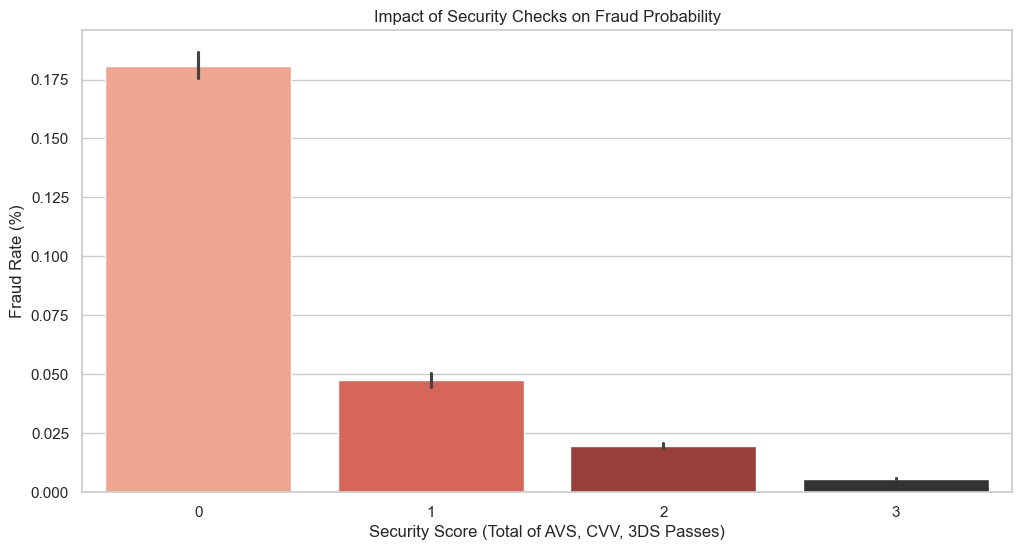

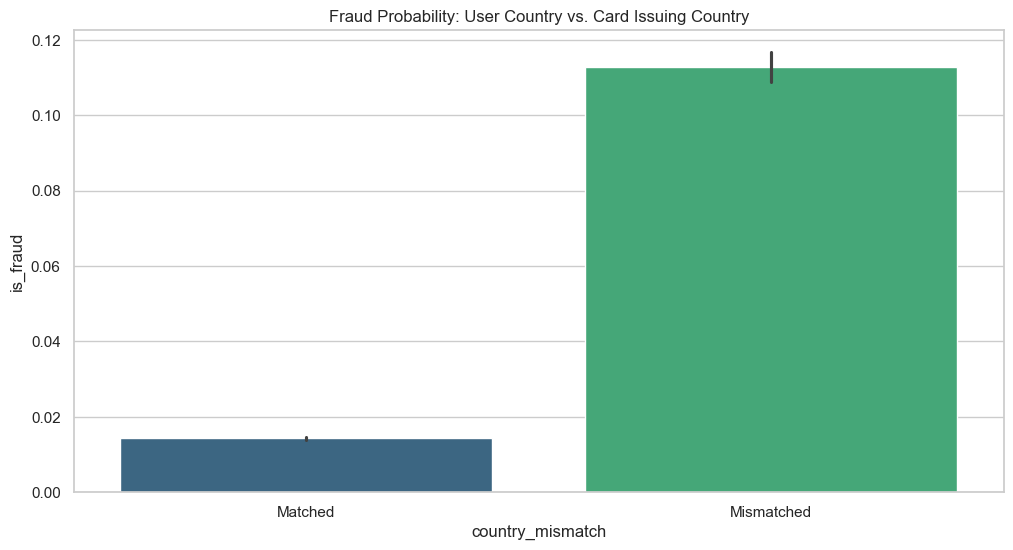

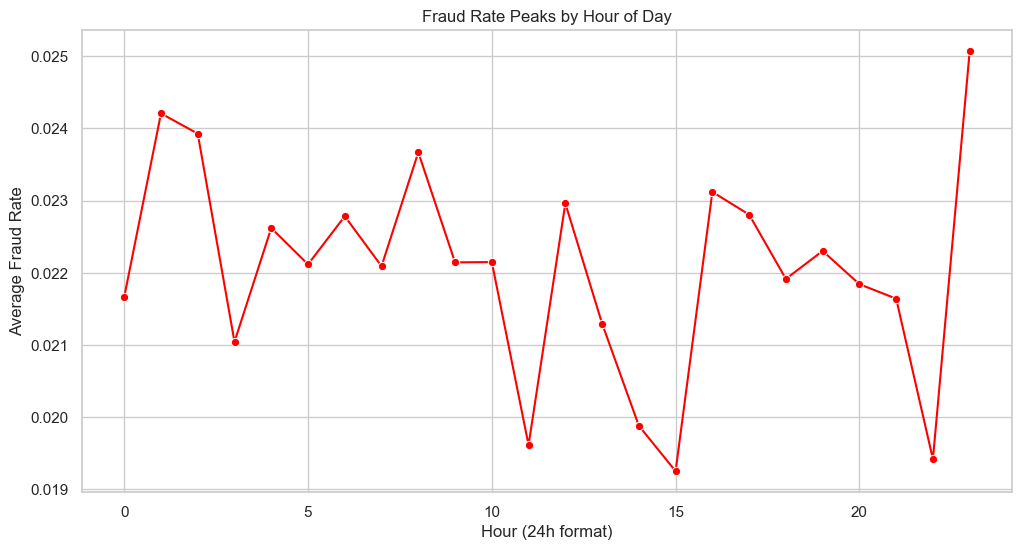

In [5]:
# 4. MAIN EXECUTION
if __name__ == "__main__":
    # Load
    data = load_and_clean('data/transactions.csv')
    
    # Process
    data = engineer_features(data)
    
    # Visualize
    run_visualizations(data)
    
    # Export for Dashboarding (Tableau/PowerBI)
    data.to_csv('data/fraud_data_enriched.csv', index=False)
    print("Success! Processed file saved as 'fraud_data_enriched.csv'")